# DELTA-D-RISE Demo

This notebook demonstrates **DELTA-D-RISE**, a detection-loss based perturbation explainability method for object detection.

The notebook shows how to:

- load an image
- load a detector and wrap it
- run the core DELTA-D-RISE explainer
- visualize saliency maps
- run the full pipeline
- inspect saved heatmaps and robustness metrics

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as T
from PIL import Image
from ultralytics import YOLO

from delta_d_rise import DeltaDRISE, DeltaDRISEConfig, run_delta_d_rise_full
from delta_d_rise.wrappers import YOLODetectionWrapper

In [2]:
print("Working directory:", os.getcwd())

Working directory: /home/rasha/Documents/delta-d-rise/notebooks


## Paths

Update these paths if needed.

This notebook assumes:
- the notebook, image and weights are in `notebooks/`

In [3]:
IMAGE_PATH = Path("../notebooks/image_095_png.rf.a26cdb47d45827e7037a01084dddf0ea.jpg")
WEIGHTS_PATH = Path("../notebooks/best.pt")
OUT_DIR = Path("../notebooks/runs/explain/DELTA_D_RISE")

print("IMAGE_PATH:", IMAGE_PATH.resolve())
print("WEIGHTS_PATH:", WEIGHTS_PATH.resolve())
print("OUT_DIR:", OUT_DIR.resolve())

IMAGE_PATH: /home/rasha/Documents/delta-d-rise/notebooks/image_095_png.rf.a26cdb47d45827e7037a01084dddf0ea.jpg
WEIGHTS_PATH: /home/rasha/Documents/delta-d-rise/notebooks/best.pt
OUT_DIR: /home/rasha/Documents/delta-d-rise/notebooks/runs/explain/DELTA_D_RISE


In [4]:
assert IMAGE_PATH.exists(), f"Image not found: {IMAGE_PATH}"
assert WEIGHTS_PATH.exists(), f"Weights not found: {WEIGHTS_PATH}"

## Load the image

Image tensor shape: torch.Size([1, 3, 720, 1280])


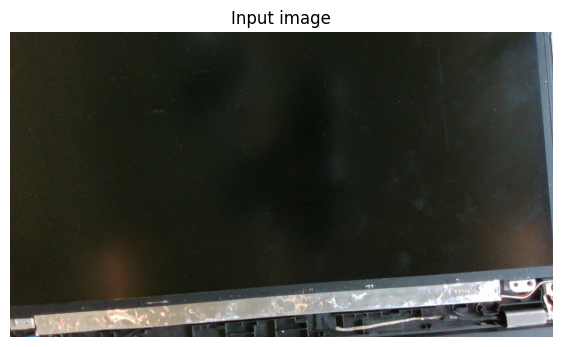

In [5]:
img_pil = Image.open(IMAGE_PATH).convert("RGB")
img_tensor = T.ToTensor()(img_pil).unsqueeze(0)

print("Image tensor shape:", img_tensor.shape)

plt.figure(figsize=(7, 7))
plt.imshow(img_pil)
plt.axis("off")
plt.title("Input image")
plt.show()

## Configure DELTA-D-RISE

In [6]:
config = DeltaDRISEConfig(
    # Number of random masks used to probe the model.
    # Higher = better saliency quality but slower runtime.
    num_masks=1500,

    # Resolution of the random mask grid (before upsampling to image size).
    # Smaller grid → coarser masks, larger grid → finer perturbations.
    mask_res=(32, 32),

    # Probability of keeping a pixel (i.e., NOT masking it).
    # Lower values = more aggressive occlusion.
    p_keep=0.93,

    # Minimum IoU required to match detections between original and masked images.
    # Lower values allow looser matching (useful for small objects).
    iou_match_threshold=0.15,

    # Weight of classification loss component (-log confidence drop).
    w_cls=1.0,

    # Weight of localization loss component (1 - IoU).
    w_loc=1.0,

    # Whether to normalize saliency maps by removing average mask bias.
    # Recommended to keep True.
    fusion_normalize=True,

    # Fill masked regions with image mean instead of zero.
    # Helps avoid introducing artificial edges.
    mean_fill=True,

    # Only match detections of the same predicted class.
    # Prevents mixing explanations across classes.
    match_same_class=True,
)

config

DeltaDRISEConfig(num_masks=1500, mask_res=(32, 32), p_keep=0.93, iou_match_threshold=0.15, w_cls=1.0, w_loc=1.0, fusion_normalize=True, mean_fill=True, match_same_class=True)

## Load detector and wrapper

In [7]:
detector = YOLO(str(WEIGHTS_PATH))
wrapper = YOLODetectionWrapper(detector, conf=0.25, imgsz=768)

## Run the core DELTA-D-RISE explainer

In [8]:
explainer = DeltaDRISE(config)
result = explainer.explain(wrapper, img_tensor, device="cpu", verbose=True)

/home/rasha/anaconda3/envs/nav_env/lib/python3.12/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
100%|██████████| 1500/1500 [02:54<00:00,  8.60it/s]


## Inspect explained detections

In [9]:
print("Number of explained detections:", len(result.detections))

for det in result.detections:
    print(
        f"det_idx={det.det_idx}, "
        f"class_id={det.class_id}, "
        f"conf={det.confidence:.3f}, "
        f"box={det.box_xyxy}"
    )

Number of explained detections: 4
det_idx=0, class_id=0, conf=0.897, box=[1176.3792  583.3432 1239.3257  614.5929]
det_idx=1, class_id=0, conf=0.836, box=[  0.      674.80646  52.88754 703.00977]
det_idx=2, class_id=1, conf=0.774, box=[1216.2393   586.46173 1233.1963   602.4394 ]
det_idx=3, class_id=2, conf=0.735, box=[6.1669981e-01 6.7951996e+02 1.6791534e+01 6.9615991e+02]


## Visualize one saliency map

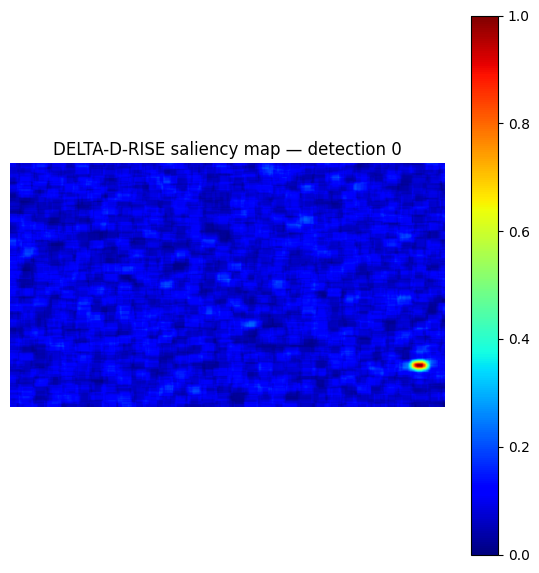

In [10]:
det0 = result.detections[0]

plt.figure(figsize=(7, 7))
plt.imshow(det0.saliency_map, cmap="jet")
plt.colorbar()
plt.title(f"DELTA-D-RISE saliency map — detection {det0.det_idx}")
plt.axis("off")
plt.show()

## Overlay the saliency map on the image

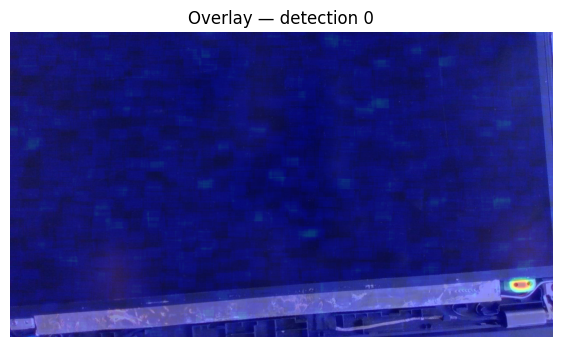

In [11]:
heat = det0.saliency_map.copy()
heat = heat - heat.min()
heat = heat / (heat.max() + 1e-9)

plt.figure(figsize=(7, 7))
plt.imshow(img_pil)
plt.imshow(heat, cmap="jet", alpha=0.45)
plt.title(f"Overlay — detection {det0.det_idx}")
plt.axis("off")
plt.show()

## Run the full DELTA-D-RISE pipeline

This reproduces the full notebook-style workflow:

- baseline detections image
- raw saliency maps
- saved heatmaps
- robustness evaluation
- summary CSV

In [12]:

report = run_delta_d_rise_full(
    # Path to input image
    image_path=str(IMAGE_PATH),

    # Wrapped object detection model
    model=wrapper,

    # Mapping from class indices to class names (for visualization)
    class_names=detector.names,

    # DELTA-D-RISE configuration (masking + loss settings)
    config=config,

    # Output directory where results (heatmaps, CSV, etc.) will be saved
    out_dir=str(OUT_DIR),

    # Device to run on ("cpu" or "cuda")
    device="cpu",

    # Show progress bars
    verbose=True,

    # Number of repeated runs for robustness evaluation
    robustness_runs=5,

    # Base random seed (each run uses seed0 + run_id)
    seed0=0,

    # Grid size used for stability/robustness analysis
    grid=(16, 16),

    # Fraction of top regions used for overlap comparison
    topk_frac=0.10,

    # Preset name (used for logging/experiments)
    preset_name="SMALL_OBJECTS",
)

100%|██████████| 1500/1500 [02:56<00:00,  8.50it/s]


## Saved artifact paths

In [13]:
print("Base detections image:")
print(report.artifacts.base_detections_image)

print("\nSummary CSV:")
print(report.artifacts.summary_csv_path)

print("\nHeatmap paths:")
for p in report.artifacts.heatmap_paths:
    print(" ", p)

print("\nRaw saliency map paths:")
for p in report.artifacts.raw_map_paths:
    print(" ", p)

Base detections image:
../notebooks/runs/explain/DELTA_D_RISE/image_095_png.rf.a26cdb47d45827e7037a01084dddf0ea_base_detections.png

Summary CSV:
../notebooks/runs/explain/DELTA_D_RISE/image_095_png.rf.a26cdb47d45827e7037a01084dddf0ea_delta_d_rise_summary.csv

Heatmap paths:
  ../notebooks/runs/explain/DELTA_D_RISE/image_095_png.rf.a26cdb47d45827e7037a01084dddf0ea_det0_delta_heat.png
  ../notebooks/runs/explain/DELTA_D_RISE/image_095_png.rf.a26cdb47d45827e7037a01084dddf0ea_det1_delta_heat.png
  ../notebooks/runs/explain/DELTA_D_RISE/image_095_png.rf.a26cdb47d45827e7037a01084dddf0ea_det2_delta_heat.png
  ../notebooks/runs/explain/DELTA_D_RISE/image_095_png.rf.a26cdb47d45827e7037a01084dddf0ea_det3_delta_heat.png

Raw saliency map paths:
  ../notebooks/runs/explain/DELTA_D_RISE/image_095_png.rf.a26cdb47d45827e7037a01084dddf0ea_det0_delta_d_rise.npy
  ../notebooks/runs/explain/DELTA_D_RISE/image_095_png.rf.a26cdb47d45827e7037a01084dddf0ea_det1_delta_d_rise.npy
  ../notebooks/runs/explain/D

## Display the saved baseline detections image

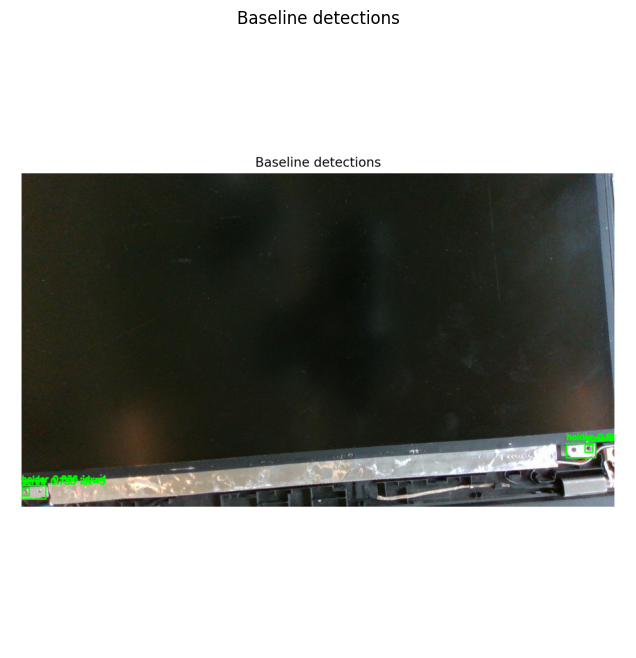

In [14]:
base_det_img = Image.open(report.artifacts.base_detections_image)

plt.figure(figsize=(8, 8))
plt.imshow(base_det_img)
plt.axis("off")
plt.title("Baseline detections")
plt.show()

## Display one saved heatmap

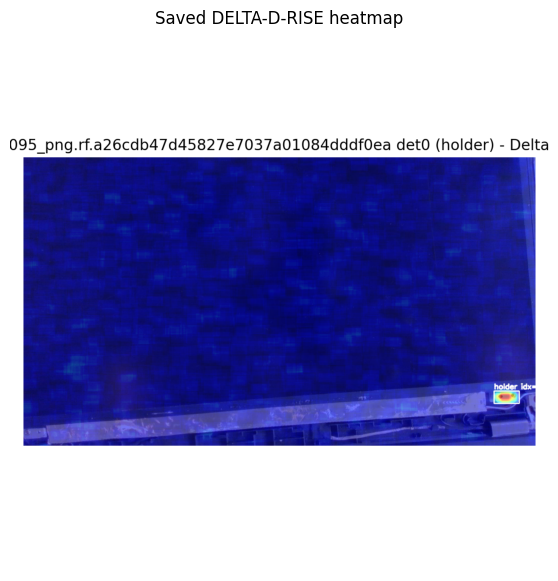

In [15]:
heatmap_img = Image.open(report.artifacts.heatmap_paths[0])

plt.figure(figsize=(7, 7))
plt.imshow(heatmap_img)
plt.axis("off")
plt.title("Saved DELTA-D-RISE heatmap")
plt.show()

## Inspect evaluation results

In [16]:
try:
    import pandas as pd

    df = pd.DataFrame([e.__dict__ for e in report.evaluations])
    display(df)
except ImportError:
    rows = [e.__dict__ for e in report.evaluations]
    rows

,image,det_idx,class_name,base_conf,x1,y1,x2,y2,robust_regions_count,robust_regions_frac,spearman_p50,topk_overlap_p50,deletion_auc_p50,io_ratio_p50,robustness_runs,grid,topk,method,preset
0,image_095_png.rf.a26cdb47d45827e7037a01084dddf0ea,0,holder,0.897445,1176.379150,583.343201,1239.325684,614.592896,8,0.031250,0.383374,0.181818,0.400552,0.012778,5,"(16, 16)",26,DELTA-D-RISE,SMALL_OBJECTS
1,image_095_png.rf.a26cdb47d45827e7037a01084dddf0ea,1,holder,0.835659,0.000000,674.806458,52.887539,703.009766,17,0.066406,0.500711,0.268293,0.166464,0.006848,5,"(16, 16)",26,DELTA-D-RISE,SMALL_OBJECTS
2,image_095_png.rf.a26cdb47d45827e7037a01084dddf0ea,2,noscrew,0.774124,1216.239258,586.461731,1233.196289,602.439392,7,0.027344,0.375335,0.209302,0.241302,0.001845,5,"(16, 16)",26,DELTA-D-RISE,SMALL_OBJECTS
3,image_095_png.rf.a26cdb47d45827e7037a01084dddf0ea,3,screw,0.734931,0.616700,679.519958,16.791534,696.159912,13,0.050781,0.483329,0.238095,0.345276,0.001361,5,"(16, 16)",26,DELTA-D-RISE,SMALL_OBJECTS


## Notes

- The **core API** returns per-detection saliency maps in memory.
- The **full pipeline API** reproduces the original workflow, including:
  - saved heatmaps
  - raw saliency maps
  - robustness metrics
  - summary CSV
- The current repository includes a **YOLO wrapper** as an example backend, while the core DELTA-D-RISE method is detector-agnostic.